# Curve Edition — The Term Premium Resurgence

**Theme:** Tracking the decoupling of long-end yields from monetary policy expectations through the 10-Year ACM Term Premium against Primary Dealer Treasury Positions, and the 10Y-2Y Yield Spread versus Net Sovereign Issuance.

> **Note:** All series below are pulled live from public sources (NY Fed, FRED, U.S. Treasury) at notebook run time.

## Charts

**Chart 1 — 10-Year ACM Term Premium vs. Primary Dealer Net Treasury Inventory (Jan 2018 – mid-2026)**  
The direct transmission from dealer balance sheet congestion to long-end risk pricing. Prior to 2022, the 10-year ACM term premium hovered in negative territory, troughing near **-1.36%** in mid-2020 as central bank asset purchases absorbed duration. As quantitative tightening commenced and federal deficits expanded, primary dealer net Treasury inventories surged toward historic capacity limits (~$540bn). In response, the term premium staged a structural reversal, breaking out of negative territory to peak near **+0.84%** by mid-2026 — evidence that saturated dealer balance sheets force private markets to demand an escalating premium to warehouse duration.

**Chart 2 — U.S. 10Y-2Y Yield Spread vs. Net Annual Sovereign Debt Issuance (2018 – late 2026)**  
The structural steepening of the U.S. yield curve against net annual sovereign debt issuance. Following the 2022–2023 inversion, where the 10Y-2Y spread reached a low near **-93bp**, the curve steepened rapidly, crossing back into positive territory in late 2024 and expanding to roughly **+68bp** by early 2026. This un-inversion did not coincide with recessionary rate cuts, but rather with net annual sovereign debt issuance (trailing 12-month change in total marketable Treasury debt) climbing past **$2.4 trillion** — supply-driven steepening as the dominant curve regime.

## Data Sources
- **Chart 1:** Federal Reserve Bank of New York (Adrian, Crump & Moench Term Premium Model, `ACMTP10`); FR 2004 Primary Dealer Government Securities Reporting.
- **Chart 2:** FRED (`DGS10`, `DGS2`); U.S. Department of the Treasury (Monthly Statement of the Public Debt / Net Issuance Datasets).


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import requests
import pandas_datareader.data as web
from datetime import datetime

plt.style.use('seaborn-v0_8-darkgrid')

START = '2018-01-01'

TODAY = datetime.today().strftime('%Y-%m-%d')
print(f'Environment ready — {TODAY}')

Environment ready — 2026-09-07


## Chart 1 — 10-Year ACM Term Premium vs. Primary Dealer Net Treasury Inventory
**Dealer balance sheet congestion transmitting into long-end risk pricing (Jan 2018 – mid-2026)**

- **10Y ACM Term Premium**: NY Fed Adrian-Crump-Moench model (`ACMTP10`) — compensation investors require for bearing long-end duration risk (monthly avg, %)
- **Primary Dealer Net Treasury Inventory**: NY Fed Primary Dealer Statistics (FR 2004), series `PDPOSGST-TOT` — net Treasury holdings (excl. TIPS) across primary dealers ($ billions)


In [22]:
# ═══════════════════════════════════════════════════════════════════
# CHART 1 DATA — LIVE PULLS
#
# Series 1 — 10-Year ACM Term Premium
#   Source: Federal Reserve Bank of New York, Adrian-Crump-Moench Model (ACMTP10)
#
# Series 2 — Primary Dealer Net Treasury Inventory ($ billions)
#   Source: NY Fed Primary Dealer Statistics (FR 2004), series PDPOSGST-TOT
# ═══════════════════════════════════════════════════════════════════

print('Fetching ACM 10-Year Term Premium from NY Fed...')
acm_url = ('https://www.newyorkfed.org/medialibrary/media/research/'
           'data_indicators/ACMTermPremium.xls')
acm_raw = pd.read_excel(acm_url, sheet_name=0, index_col=0, parse_dates=True)
term_premium_daily = acm_raw['ACMTP10'].dropna()
term_premium = term_premium_daily.resample('MS').mean().loc[START:]
term_premium.name = 'acm_term_premium_10y'
print(f'  ✓ Term premium: {len(term_premium)} monthly obs '
      f'({term_premium.index[0].date()} → {term_premium.index[-1].date()})')

print('\nFetching primary dealer net Treasury positions from NY Fed Markets API...')
pd_url = 'https://markets.newyorkfed.org/api/pd/get/PDPOSGST-TOT.csv'
dealer_raw = pd.read_csv(pd_url, parse_dates=['As Of Date'], index_col='As Of Date')
dealer_weekly = dealer_raw['Value (millions)'].sort_index() / 1000  # millions -> billions
dealer_inventory = dealer_weekly.resample('MS').mean().loc[START:]
dealer_inventory.name = 'dealer_net_inventory_bn'
print(f'  ✓ Dealer inventory: {len(dealer_inventory)} monthly obs '
      f'({dealer_inventory.index[0].date()} → {dealer_inventory.index[-1].date()})')

df_c1 = pd.DataFrame({
    'acm_term_premium_10y':   term_premium,
    'dealer_net_inventory_bn': dealer_inventory,
}).dropna()
df_c1.to_csv('data/curve_chart1_data.csv')
print(f'\n✓ Saved → data/curve_chart1_data.csv')


Fetching ACM 10-Year Term Premium from NY Fed...
  ✓ Term premium: 104 monthly obs (2018-01-01 → 2026-08-01)

Fetching primary dealer net Treasury positions from NY Fed Markets API...
  ✓ Dealer inventory: 104 monthly obs (2018-01-01 → 2026-08-01)

✓ Saved → data/curve_chart1_data.csv


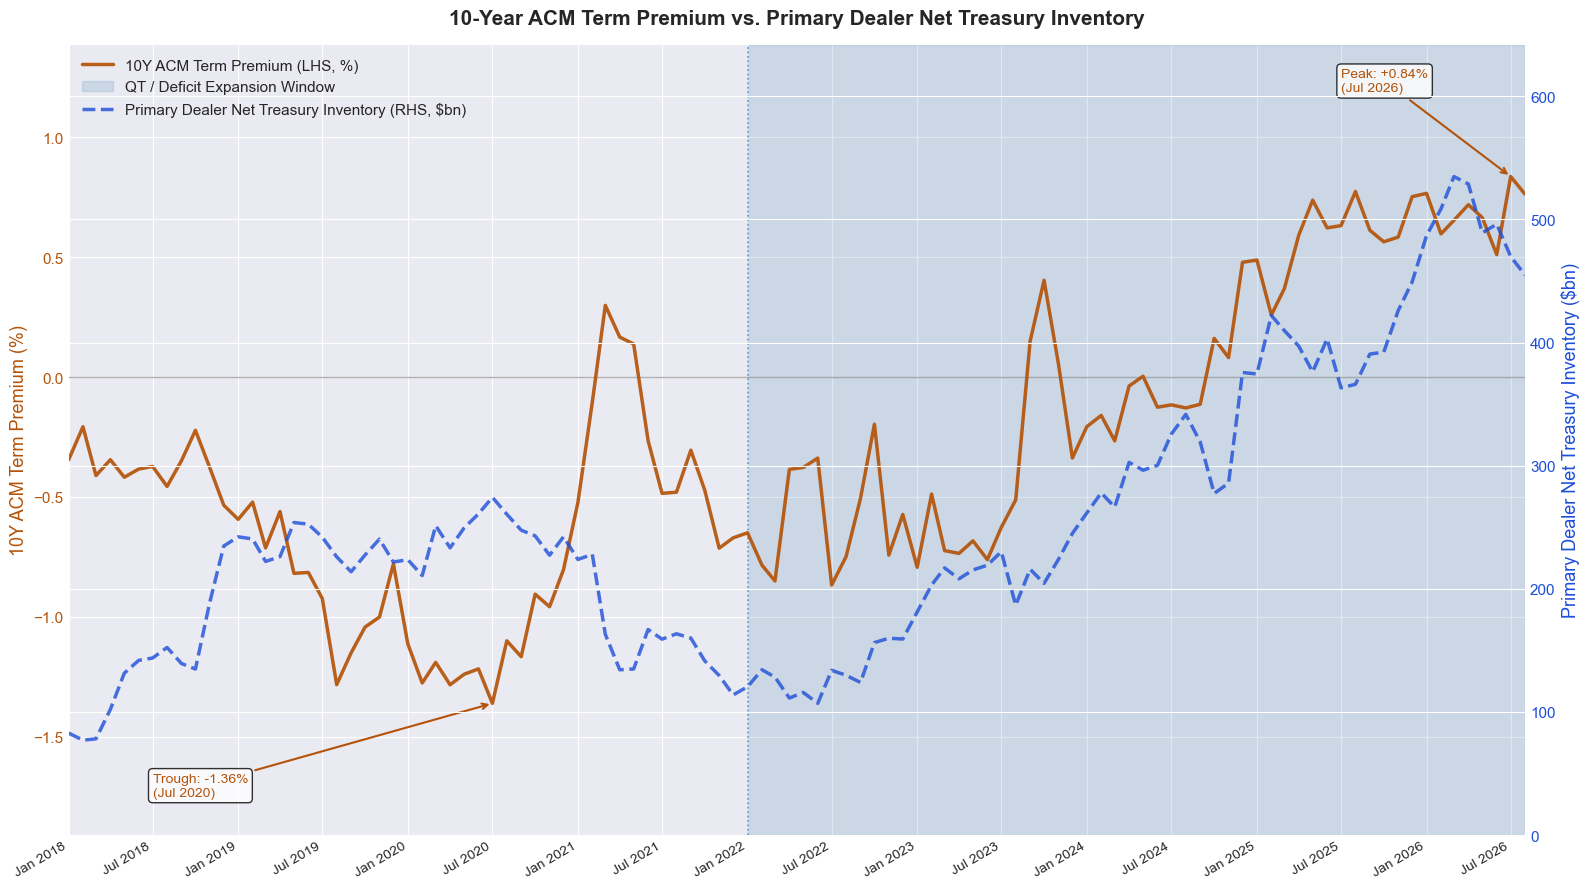

✓ Chart 1 saved → data/chart1_term_premium_vs_dealer_inventory.png


In [28]:
fig, ax1 = plt.subplots(figsize=(16, 9))

color_tp      = '#b45309'
color_dealer  = '#1d4ed8'

pre_qt_trough_val  = term_premium.loc[term_premium.index < '2022-01'].min()
pre_qt_trough_date = term_premium.loc[term_premium.index < '2022-01'].idxmin()
tp_peak_val        = term_premium.max()
tp_peak_date       = term_premium.idxmax()

tp_range = tp_peak_val - pre_qt_trough_val
tp_pad   = tp_range * 0.25
tp_ylim  = (term_premium.min() - tp_pad, term_premium.max() + tp_pad)

# ── Left axis: ACM Term Premium ──────────────────────────────────
ax1.plot(term_premium.index, term_premium.values,
         color=color_tp, linewidth=2.5, alpha=0.92, zorder=5,
         label='10Y ACM Term Premium (LHS, %)')
ax1.axhline(0, color='grey', linewidth=1.0, alpha=0.6, linestyle='-')

ax1.annotate(f'Trough: {pre_qt_trough_val:.2f}%\n({pre_qt_trough_date.strftime("%b %Y")})',
             xy=(pre_qt_trough_date, pre_qt_trough_val),
             xytext=(term_premium.index[6], tp_ylim[0] + tp_pad * 0.3),
             fontsize=10, color=color_tp,
             arrowprops=dict(arrowstyle='->', color=color_tp, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax1.annotate(f'Peak: +{tp_peak_val:.2f}%\n({tp_peak_date.strftime("%b %Y")})',
             xy=(tp_peak_date, tp_peak_val),
             xytext=(term_premium.index[-14], tp_ylim[1] - tp_pad * 0.35),
             fontsize=10, color=color_tp,
             arrowprops=dict(arrowstyle='->', color=color_tp, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax1.set_ylabel('10Y ACM Term Premium (%)', fontsize=13, color=color_tp)
ax1.set_ylim(*tp_ylim)
ax1.tick_params(axis='y', labelcolor=color_tp, labelsize=11)

# ── Right axis: Primary Dealer Net Treasury Inventory ────────────
ax2 = ax1.twinx()
ax2.plot(dealer_inventory.index, dealer_inventory.values,
         color=color_dealer, linewidth=2.5, alpha=0.80,
         linestyle='--', zorder=4,
         label='Primary Dealer Net Treasury Inventory (RHS, $bn)')

ax2.set_ylabel('Primary Dealer Net Treasury Inventory ($bn)',
               fontsize=13, color=color_dealer)
ax2.set_ylim(0, dealer_inventory.max() * 1.2)
ax2.tick_params(axis='y', labelcolor=color_dealer, labelsize=11)

ax1.axvspan(pd.Timestamp('2022-01'), term_premium.index[-1],
            alpha=0.18, color='steelblue', label='QT / Deficit Expansion Window')
ax1.axvline(pd.Timestamp('2022-01'), color='steelblue', linewidth=1.2,
            linestyle=':', alpha=0.8)

# ── Formatting ────────────────────────────────────────────────────
ax1.set_xlim(term_premium.index.min(), term_premium.index.max())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=11, framealpha=0.9)

plt.title('10-Year ACM Term Premium vs. Primary Dealer Net Treasury Inventory',
          fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('data/chart1_term_premium_vs_dealer_inventory.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 1 saved → data/chart1_term_premium_vs_dealer_inventory.png')


## Chart 2 — U.S. 10Y-2Y Yield Spread vs. Net Annual Sovereign Debt Issuance
**Supply-driven steepening of the yield curve (2018 – late 2026)**

- **10Y-2Y Yield Spread**: FRED `DGS10` minus `DGS2` (monthly avg, bp)
- **Net Annual Sovereign Debt Issuance**: U.S. Department of the Treasury, Monthly Statement of the Public Debt (`mspd_table_1`, Total Marketable debt outstanding) — trailing 12-month change, sampled annually ($ trillions)


In [30]:
# ═══════════════════════════════════════════════════════════════════
# CHART 2 DATA — LIVE PULLS
#
# Series 1 — 10Y-2Y Yield Spread (bp)
#   Source: FRED DGS10 - DGS2
#
# Series 2 — Net Annual Sovereign Debt Issuance ($ trillions)
#   Source: U.S. Treasury Fiscal Data API, MSPD Table 1 (Total Marketable debt
#   outstanding) — trailing 12-month change, sampled once per year
# ═══════════════════════════════════════════════════════════════════

print('Fetching DGS10 and DGS2 from FRED...')
dgs10 = web.DataReader('DGS10', 'fred', START, TODAY)['DGS10'].dropna()
dgs2  = web.DataReader('DGS2',  'fred', START, TODAY)['DGS2'].dropna()
spread_daily = ((dgs10 - dgs2) * 100).dropna()  # percentage points -> bp
yield_spread = spread_daily.resample('MS').mean()
yield_spread.name = 'spread_10y2y_bp'
print(f'  ✓ 10Y-2Y spread: {len(yield_spread)} monthly obs '
      f'({yield_spread.index[0].date()} → {yield_spread.index[-1].date()})')

print('\nFetching Total Marketable debt outstanding from U.S. Treasury Fiscal Data API...')
treasury_url = 'https://api.fiscaldata.treasury.gov/services/api/fiscal_service/v1/debt/mspd/mspd_table_1'
mkt_debt_start = (pd.Timestamp(START) - pd.DateOffset(years=1)).strftime('%Y-%m-%d')
params = {
    'fields': 'record_date,security_type_desc,total_mil_amt',
    'filter': f'record_date:gte:{mkt_debt_start},security_type_desc:eq:Total Marketable',
    'sort': 'record_date',
    'page[size]': 500,
}
resp = requests.get(treasury_url, params=params, timeout=30).json()
mkt_debt = pd.DataFrame(resp['data'])
mkt_debt['record_date'] = pd.to_datetime(mkt_debt['record_date'])
mkt_debt['total_mil_amt'] = mkt_debt['total_mil_amt'].astype(float)
mkt_debt = mkt_debt.set_index('record_date')['total_mil_amt'].sort_index()

# Trailing 12-month change in total marketable debt outstanding = net issuance ($tn)
net_issuance_ttm = ((mkt_debt - mkt_debt.shift(12)) / 1e6).dropna()
net_issuance_by_year = net_issuance_ttm.groupby(net_issuance_ttm.index.year).last()
net_issuance = pd.Series(
    net_issuance_by_year.values,
    index=pd.to_datetime([f'{y}-07-01' for y in net_issuance_by_year.index]),
)
net_issuance.name = 'net_issuance_usd_tn'
print(f'  ✓ Net annual issuance: {len(net_issuance)} annual obs '
      f'({net_issuance.index[0].date()} → {net_issuance.index[-1].date()})')

df_c2 = pd.concat([yield_spread, net_issuance], axis=1)
df_c2.to_csv('data/curve_chart2_data.csv')
print(f'\n✓ Saved → data/curve_chart2_data.csv')

Fetching DGS10 and DGS2 from FRED...
  ✓ 10Y-2Y spread: 105 monthly obs (2018-01-01 → 2026-09-01)

Fetching Total Marketable debt outstanding from U.S. Treasury Fiscal Data API...
  ✓ Net annual issuance: 9 annual obs (2018-07-01 → 2026-07-01)

✓ Saved → data/curve_chart2_data.csv


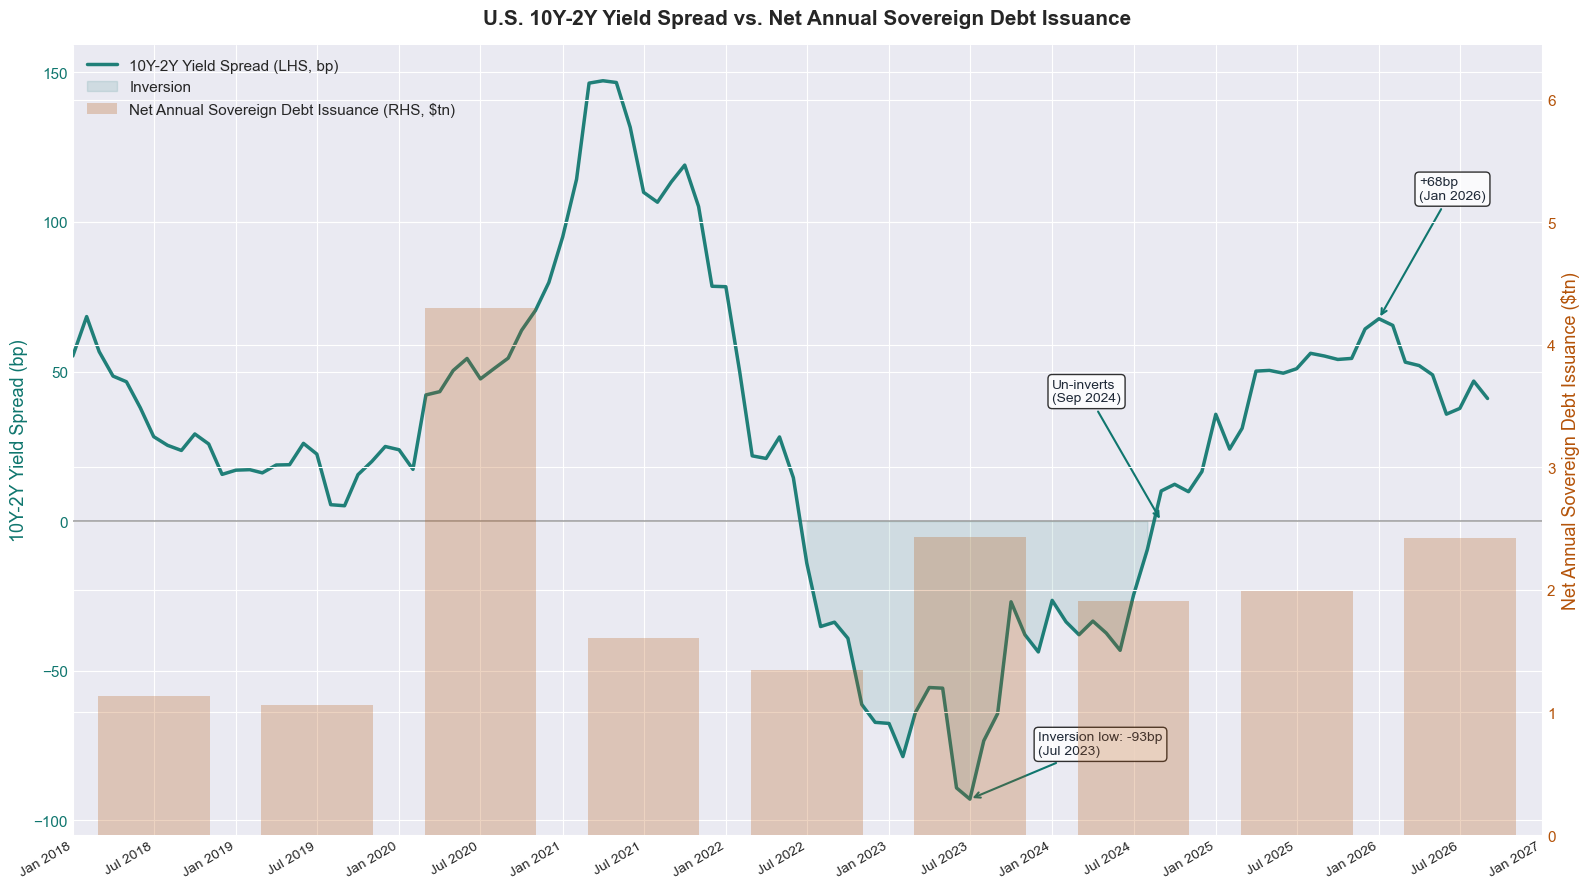

✓ Chart 2 saved → data/chart2_spread_vs_issuance.png


In [33]:
fig, ax1 = plt.subplots(figsize=(16, 9))

color_spread   = '#0f766e'
color_issuance = '#b45309'

trough_val  = yield_spread.min()
trough_date = yield_spread.idxmin()
peak_val    = yield_spread.loc[yield_spread.index >= '2025-01'].max()
peak_date   = yield_spread.loc[yield_spread.index >= '2025-01'].idxmax()
uninvert_date = yield_spread.loc[(yield_spread.index >= '2024-01') &
                                  (yield_spread > 0)].index[0]

# ── Left axis: 10Y-2Y spread ──────────────────────────────────────
ax1.plot(yield_spread.index, yield_spread.values,
         color=color_spread, linewidth=2.5, alpha=0.92, zorder=5,
         label='10Y-2Y Yield Spread (LHS, bp)')
ax1.axhline(0, color='grey', linewidth=1.2, alpha=0.7, linestyle='-')
ax1.fill_between(yield_spread.index, yield_spread.values, 0,
                 where=(yield_spread.values < 0), alpha=0.12, color=color_spread,
                 label='Inversion')

ax1.annotate(f'Inversion low: {trough_val:.0f}bp\n({trough_date.strftime("%b %Y")})',
             xy=(trough_date, trough_val),
             xytext=(trough_date + pd.DateOffset(months=5), trough_val + 15),
             fontsize=10, color='#1f2937',
             arrowprops=dict(arrowstyle='->', color=color_spread, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax1.annotate(f'Un-inverts\n({uninvert_date.strftime("%b %Y")})',
             xy=(uninvert_date, 0),
             xytext=(uninvert_date - pd.DateOffset(months=8), 40),
             fontsize=10, color='#1f2937',
             arrowprops=dict(arrowstyle='->', color=color_spread, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax1.annotate(f'+{peak_val:.0f}bp\n({peak_date.strftime("%b %Y")})',
             xy=(peak_date, peak_val),
             xytext=(yield_spread.index[-6], peak_val + 40),
             fontsize=10, color='#1f2937',
             arrowprops=dict(arrowstyle='->', color=color_spread, lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax1.set_ylabel('10Y-2Y Yield Spread (bp)', fontsize=13, color=color_spread)
ax1.tick_params(axis='y', labelcolor=color_spread, labelsize=11)

# ── Right axis: net annual sovereign issuance (bars) ─────────────
ax2 = ax1.twinx()
bar_width = 250  # days, roughly one year wide
ax2.bar(net_issuance.index, net_issuance.values,
        width=bar_width, color=color_issuance, alpha=0.25,
        align='center', label='Net Annual Sovereign Debt Issuance (RHS, $tn)')

ax2.set_ylabel('Net Annual Sovereign Debt Issuance ($tn)',
               fontsize=13, color=color_issuance)
ax2.set_ylim(0, net_issuance.max() * 1.5)
ax2.tick_params(axis='y', labelcolor=color_issuance, labelsize=11)

# ── Formatting ────────────────────────────────────────────────────
ax1.set_xlim(yield_spread.index.min(), yield_spread.index.max() + pd.DateOffset(months=4))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=10)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=11, framealpha=0.9)

plt.title('U.S. 10Y-2Y Yield Spread vs. Net Annual Sovereign Debt Issuance',
          fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('data/chart2_spread_vs_issuance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Chart 2 saved → data/chart2_spread_vs_issuance.png')


---

## Sources

**Chart 1:** Federal Reserve Bank of New York (Adrian, Crump & Moench Term Premium Model, `ACMTP10`); NY Fed Primary Dealer Statistics (FR 2004), series `PDPOSGST-TOT`.

**Chart 2:** FRED `DGS10`, `DGS2`; U.S. Department of the Treasury Fiscal Data API, Monthly Statement of the Public Debt (`mspd_table_1`).

*All series are pulled live from the sources above at notebook run time.*
